# Split-RAG experiments
This notebook consists of the most important experiments conducted for the Split-RAG architecture.

**Baseline RAGAs results**: 
* faithfulness: 0.7205 
* factual correctness: 0.3340
* context precision: 0.8750
* context recall: 0.3417

## Imports

In [86]:
import os
import time
import pandas as pd
import numpy as np
import json
import matplotlib as plt
import seaborn as sns
from datasets import Dataset
from dotenv import load_dotenv

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_openai import AzureOpenAIEmbeddings
from langchain_chroma import Chroma
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from openai import AsyncAzureOpenAI
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_classic.retrievers import BM25Retriever
from langchain_classic.storage import LocalFileStore, create_kv_docstore



from ragas.metrics import Faithfulness, FactualCorrectness, ContextPrecision, ContextRecall
from ragas.llms import llm_factory
import nest_asyncio
from ragas import aevaluate 
from ragas import RunConfig



C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\1312539639.py:24: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, FactualCorrectness, ContextPrecision, ContextRecall
C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\1312539639.py:24: DeprecationWarning: Importing FactualCorrectness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import FactualCorrectness
  from ragas.metrics import Faithfulness, FactualCorrectness, ContextPrecision, ContextRecall
C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\1312539639.py:24: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' inst

## Environment variables

In [2]:
env_path = os.path.join("..", ".env")
load_dotenv(dotenv_path=env_path)

endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
api_version = os.getenv("AZURE_OPENAI_API_VERSION")
embedding_deployment = os.getenv("AZURE_EMBEDDING_DEPLOYMENT")
deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT")

# Initialize Azure AD token provider
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)

## Data Loading
In contrast to the baseline experiments, the Split-RAG architecture employs a decoupled data strategy. Rather than treating legislation and jurisprudence as a unified corpus, this approach maintains them as two distinct, specialized knowledge bases.

In [3]:
legislation_path = '../data/legislation_omgevingswet_cleaned.jsonl'
jurisprudence_path = '../data/jurisprudence_omgevingswet_cleaned.jsonl'

common_cols = ['id', 'title', 'text', 'word_count', 'source_type']
df_legislation = pd.read_json(legislation_path, lines=True)
df_jurisprudence = pd.read_json(jurisprudence_path, lines=True)

df_leg_sub = df_legislation[common_cols]
df_jur_sub = df_jurisprudence[common_cols]

print(f"Legislation loaded: {len(df_legislation)} rows")
print(f"Jurisprudence loaded: {len(df_jurisprudence)} rows")

Legislation loaded: 725 rows
Jurisprudence loaded: 3404 rows


In [ ]:
# Legislation document creation
docs_legislation = [
    Document(
        page_content=str(row['text']),
        metadata={
            "id": row['id'],
            "title": row['title'],
            "source_type": row['source_type'],
            "word_count": row['word_count']
        }
    ) for _, row in df_leg_sub.iterrows()
]

# Jurisprudence document creation
docs_jurisprudence = [
    Document(
        page_content=str(row['text']),
        metadata={
            "id": row['id'],
            "title": row['title'],
            "source_type": row['source_type'],
            "word_count": row['word_count']
        }
    ) for _, row in df_jur_sub.iterrows()
]

print(f"Created {len(docs_legislation)} legislation documents.")
print(f"Created {len(docs_jurisprudence)} jurisprudence documents.")

Created 725 legislation documents.
Created 3404 jurisprudence documents.


# Retrieving documents per dataset

In [5]:
embeddings = AzureOpenAIEmbeddings(
    azure_deployment=embedding_deployment, 
    azure_endpoint=endpoint,              
    openai_api_version=api_version,       
    azure_ad_token_provider=token_provider
)

## Legislation
For legislation, we are implementing a **Parent Document Retrieval (PDR)** system. Instead of standard chunking, this system employs a hierarchical approach.

**Rationale:**
Laws are inherently hierarchical and logically structured. Recent research (Lim et al., 2025; Guo et al., 2025) demonstrates that multi-granular context is superior to fixed chunk sizes. By indexing small child chunks (400 tokens), we maximise search precision. However, to prevent the AI from losing the legal context, the full parent” article is served to the model as context upon a match. This chunk-to-context reconstruction directly addresses the shortcomings of naive RAG systems when dealing with complex legislation (Lim et al., 2025).


In [6]:
# Splitter for search chunks (childs)
child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400, 
    chunk_overlap=50
)

# Define paths
vdb_base_path = "../data/vector_stores"
leg_child_path = os.path.join(vdb_base_path, "split_legislation_child")
leg_parent_path = os.path.join(vdb_base_path, "split_legislation_parent_store")

# Parent storage for disk
fs = LocalFileStore(leg_parent_path)
parent_docstore = create_kv_docstore(fs) 

# Child database
vdb_leg_child = Chroma(
    collection_name="leg_pdr_final",
    embedding_function=embeddings, 
    persist_directory=leg_child_path
)

# Retriever that links child chunks (cosine similarity)
retriever_leg_parent = ParentDocumentRetriever(
    vectorstore=vdb_leg_child,
    docstore=parent_docstore,
    child_splitter=child_splitter,
)

In [7]:
# Check if disk is empty and populate using unique, stable IDs
if vdb_leg_child._collection.count() == 0:
    print("Vectordatabase empty. Indexing legislation documents...")
    batch_size = 50
    
    for i in range(0, len(docs_legislation), batch_size):
        batch = docs_legislation[i : i + batch_size]
        
        # Extract fixed unique IDs from document metadata
        batch_ids = [str(doc.metadata["id"]) for doc in batch]
        
        # Populate parent docstore and child vector store simultaneously
        retriever_leg_parent.add_documents(batch, ids=batch_ids)
        
        print(f"Progress: {min(i + batch_size, len(docs_legislation))}/{len(docs_legislation)} articles done")
        time.sleep(1)
        
    # Force persistence to disk
    if hasattr(vdb_leg_child, 'persist'):
        vdb_leg_child.persist()
        
    print(f"Database is ready. Total chunks: {vdb_leg_child._collection.count()}")
else:
    print(f"Database is ready. Loaded {vdb_leg_child._collection.count()} chunks from disk.")

Database is ready. Loaded 4100 chunks from disk.


## Jurisprudence
For the jurisprudence, we use Structure-Aware Chunking.

**Rationale:**
Jurisprudence is narrative and story-driven in nature, meaning that relevant information is often scattered across lengthy texts. In line with the findings in *LegalBench-RAG* (Pipitone & Alami, 2024), standard retrieval is often insufficient for this type of document. We use a splitter that preserves the logical integrity of the judgment (splitting by ECLI and paragraphs). 

In [ ]:
structure_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=150,
    length_function=len,
    separators=[
        "\nECLI:",          
        "\n\n",            
        "\n",             
        ". ",              
        " "               
    ]
)

# Apply splitter to jurisprudence documents
chunks_juris_structure = structure_splitter.split_documents(docs_jurisprudence)

print(f"Jurisprudence: Structure-Aware Results")
print(f"Totaal aantal chunks: {len(chunks_juris_structure)}")

# Check first chunk
if chunks_juris_structure:
    print(f"\nSample Metadata: {chunks_juris_structure[0].metadata}")
    print(f"Sample Content: {chunks_juris_structure[0].page_content[:300]}...")

Jurisprudence: Structure-Aware Results
Totaal aantal chunks: 51321

Sample Metadata: {'id': 'ECLI:NL:RBGEL:2024:26', 'title': 'ECLI:NL:RBGEL:2024:26, Rechtbank Gelderland, 05-01-2024, AWB-22_5249 en 22_5252', 'source_type': 'jurisprudence', 'word_count': 2403}
Sample Content: Weigering handhavingsverzoeken m.b.t. geitenhouderij. Intern salderen. Beroep gegrond vanwege een motiveringsgebrek. De rechtsgevolgen worden door de rechtbank in stand gelaten omdat in het verweerschrift afdoende is onderbouwd dat er geen sprake is van een overtreding van de Wnb.


    

Zittingspl...


In [ ]:
def create_vdb_in_batches(chunks, path, name, embeddings, batch_size=50):
    print(f"Checking existing progress for: {name}")
    
    # Set up the database connection
    vector_db = Chroma(
        persist_directory=path,
        embedding_function=embeddings
    )
    
    existing_count = vector_db._collection.count()
    
    # See if we can resume or need to start fresh
    if existing_count > 0:
        print(f"Resuming: Found {existing_count} chunks already in database.")
        remaining_chunks = chunks[existing_count:]
    else:
        print("No existing data found. Starting from scratch.")
        remaining_chunks = chunks

    if not remaining_chunks:
        print(f"All chunks for {name} are already processed.\n")
        return vector_db

    print(f"Adding {len(remaining_chunks)} remaining chunks...")
    
    # Loop through the remaining chunks in batches
    for i in range(0, len(remaining_chunks), batch_size):
        batch = remaining_chunks[i : i + batch_size]
        vector_db.add_documents(documents=batch)
        
        current_total = existing_count + i + len(batch)
        print(f"Progress for {name}: {current_total}/{len(chunks)} chunks total.")
        
        # Pause to avoid API rate limits and let disk save data
        time.sleep(1) 
        
    print(f"{name} successfully updated at {path}\n")
    return vector_db

# Jurisprudence configuration
juris_vdb_path = os.path.join(vdb_base_path, "split_jurisprudence_structure")

vdb_juris_split = create_vdb_in_batches(
    chunks=chunks_juris_structure, 
    path=juris_vdb_path, 
    name="Jurisprudence-Structure",
    embeddings=embeddings,
    batch_size=50
)

Checking existing progress for: Jurisprudence-Structure
Hervatten: Er staan al 51321 chunks in de database.
Alle chunks voor Jurisprudence-Structure zijn al verwerkt!



In [10]:
# Load database
vdb_juris_split = Chroma(
    persist_directory=os.path.join(vdb_base_path, "split_jurisprudence_structure"),
    embedding_function=embeddings
)

print(f"Jurisprudence chunks geladen: {vdb_juris_split._collection.count()}")

Jurisprudence chunks geladen: 51321


In [11]:
retriever_juris_structure = vdb_juris_split.as_retriever(
    search_type="mmr", 
    search_kwargs={
        "k": 15,                # fetch 15 fragments
        "fetch_k": 50,          # fetch 50 and retrieve 15 most diverse
        "lambda_mult": 0.5      # balance between relevance and diversity
    }
)

## Split-RAG

In [12]:
vdb_path = "../data/vector_stores"

vdb_leg_child = Chroma(
    persist_directory=os.path.join(vdb_path, "split_legislation_child"),
    embedding_function=embeddings
)

# Load parent store (complete articles)
fs_leg = LocalFileStore(os.path.join(vdb_path, "split_legislation_parent_store"))
parent_docstore = create_kv_docstore(fs_leg)

vdb_juris_split = Chroma(
    persist_directory=os.path.join(vdb_path, "split_jurisprudence_structure"),
    embedding_function=embeddings
)

# Check chunk counts for your Split-RAG architecture
print(f"Split-RAG Legislation chunks: {vdb_leg_child._collection.count()}")
print(f"Split-RAG Jurisprudence chunks: {vdb_juris_split._collection.count()}")

Split-RAG Legislation chunks: 2050
Split-RAG Jurisprudence chunks: 51321


## RAGAs evaluation

### QA pairs

In [ ]:
# Load JSON file
file_path = "../data/QA_pairs_evaluation.json" 

with open(file_path, 'r', encoding='utf-8') as f:
    qa_list = json.load(f)

# Convert to DataFrame
df_qa = pd.DataFrame(qa_list)
print(f"Dataset loaded: {len(df_qa)} questions found.")

Dataset geladen: 10 vragen gevonden.


### RAGAs dataset generations

In [14]:
client = AsyncAzureOpenAI(
    azure_endpoint=endpoint,
    azure_deployment=deployment,
    api_version=api_version,
    azure_ad_token_provider=token_provider,
)

In [15]:
# retriever run 1 & 2
ensemble_retriever = EnsembleRetriever(
    retrievers=[retriever_leg_parent, retriever_juris_structure],
    weights=[0.6, 0.4] 
)

In [ ]:
async def run_evaluation_loop(retriever, dataset_list, strategy_name): 
    questions = []
    all_contexts = []
    ground_truths = []
    all_answers = []

    system_prompt = (
    "Je bent een juridisch assistent voor de Gemeente Amsterdam.\n"
    "Beantwoord de vraag zo nauwkeurig mogelijk, uitsluitend op basis van de verstrekte context.\n"
    "Formuleer een helder en logisch juridisch advies. Als het antwoord niet in de context "
    "te vinden is, geef dit dan expliciet aan."
    "Geef antwoord in een lopende tekst zonder opmaak."
)


    print(f"Start retrieval and generation for: {strategy_name}...")

    for item in dataset_list:
        q = item['question']
        gt = item['ground_truth']
        
        # Retrieval
        docs = retriever.invoke(q) 
        ctx_list = [doc.page_content for doc in docs]
        context_text = "\n\n".join(ctx_list)
        
        # Generation
        resp = await client.chat.completions.create(
            model=deployment,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Context: {context_text}\n\nVraag: {q}"},
            ],
            temperature=0 
        )
        answer = resp.choices[0].message.content
        
        # Save to lists
        questions.append(q)
        all_contexts.append(ctx_list) 
        ground_truths.append(gt)
        all_answers.append(answer)

    # Dataset object for RAGAs
    ds = Dataset.from_dict({
        "question": questions,
        "answer": all_answers,
        "contexts": all_contexts,
        "ground_truth": ground_truths
    })
    
    os.makedirs("../data/results", exist_ok=True)
    ds.to_pandas().to_csv(f"../data/results/results_{strategy_name}.csv", index=False, encoding='utf-16')
    
    return ds

## Results and analysis

In [17]:
evaluator_llm = llm_factory(
    model=deployment,
    client=client,
    max_tokens=4096
    )

config = RunConfig(
    timeout=240,     
    max_retries=20, 
    max_wait=60,
    max_workers=1,
    seed=42,      
)

nest_asyncio.apply()

# Initialize metrics
metrics = [
    Faithfulness(llm=evaluator_llm),
    FactualCorrectness(llm=evaluator_llm), 
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm)
]




# BM25 retriever + MMR
The initial results of the Split-RAG model show high faithfulness (0.85), but lower factual correctness (0.36) and context precision (0.46). This indicates embedding dilution: crucial legal identifiers, such as article numbers and ECLI references, become diluted in the semantic vector space (S & Easwarakumar, 2025).

To improve factual accuracy, a BM25Retriever has been added to the ensemble. Whereas the current vector search focuses on meaning, BM25 enforces precision based on exact keyword matches (lexical matching). This hybrid intervention is necessary to reduce noise in the context and restore the direct link between the query and the specific legal source.

In parallel, Maximum Marginal Relevance (MMR) filtering is introduced to optimize the jurisprudence retrieval channel. Because judicial rulings in Dutch administrative law are inherently narrative and lengthy, standard similarity searches frequently retrieve highly redundant context fragments that reiterate the same legal facts or definitions. This textual redundancy overloads the LLM's limited context window without introducing new information, further driving down context precision and confusing the generator. By implementing MMR, the pipeline actively penalizes redundant text segments and prioritizes information diversity. This ensures that the retrieved context contains a broader, more distinct range of legal perspectives and factual nuances necessary to formulate a comprehensive legal justification.

In [18]:
# Branch 1: Legislation (PDR + BM25) 
# Fetch documents from vectorstore and handle string conversion safely
leg_data = vdb_leg_child.get()
raw_documents_leg = leg_data.get('documents', []) if leg_data else []

processed_texts_leg = [
    doc.page_content if hasattr(doc, 'page_content') else str(doc) 
    for doc in raw_documents_leg if doc is not None
]

if not processed_texts_leg:
    print("CRITICAL ERROR: 'processed_texts_leg' is empty!")
    print("Please verify that 'vdb_leg_child' is filled and properly initialized.")
    processed_texts_leg = ["Fallback context to prevent zero division error during testing."]

# Initialize sparse keyword retriever for legislation
retriever_leg_bm25 = BM25Retriever.from_texts(processed_texts_leg)
retriever_leg_bm25.k = 5

# Combine retrievers
hybrid_leg = EnsembleRetriever(
    retrievers=[retriever_leg_parent, retriever_leg_bm25], 
    weights=[0.5, 0.5]
)

# Branch 2: Jurisprudence (MMR + BM25)
# Configure dense vector retriever to use MMR to reduce redundancy
retriever_juris_mmr = vdb_juris_split.as_retriever(
    search_type="mmr", 
    search_kwargs={"k": 15, "fetch_k": 50, "lambda_mult": 0.5}
)


# Fetch jurisprudence documents in batches
processed_texts_juris = []
batch_limit = 10000
offset = 0

print("Fetching jurisprudence chunks in batches from disk...")
while True:
    juris_batch = vdb_juris_split.get(limit=batch_limit, offset=offset)
    raw_docs_juris_batch = juris_batch.get('documents', []) if 'juri_batch' in locals() else juris_batch.get('documents', [])
    
    if not raw_docs_juris_batch:
        break
        
    for doc in raw_docs_juris_batch:
        if doc is not None:
            processed_texts_juris.append(doc.page_content if hasattr(doc, 'page_content') else str(doc))
            
    print(f"Loaded database batch: chunks collected so far: {len(processed_texts_juris)}")
    
    if len(raw_docs_juris_batch) < batch_limit:
        break
    offset += batch_limit

# Explicit guard for the jurisprudence pipeline
if not processed_texts_juris:
    print("erro: 'processed_texts_juris' is empty!")
    print("Please verify that 'vdb_juris_split' is filled and properly initialized.")
    processed_texts_juris = ["Fallback context to prevent zero division error during testing."]

# Initialize sparse keyword retriever for jurisprudence
retriever_juris_bm25 = BM25Retriever.from_texts(processed_texts_juris)
retriever_juris_bm25.k = 10

# Combine retrievers using an equal 50/50 balance
hybrid_juris = EnsembleRetriever(
    retrievers=[retriever_juris_mmr, retriever_juris_bm25], 
    weights=[0.5, 0.5]
)

# Retriever run 3 (0.6 legislation, 0.4 jurisprudence)
hybrid_ensemble = EnsembleRetriever(
    retrievers=[hybrid_leg, hybrid_juris],
    weights=[0.6, 0.4]
)


Fetching jurisprudence chunks in batches from disk...
Loaded database batch: chunks collected so far: 10000
Loaded database batch: chunks collected so far: 20000
Loaded database batch: chunks collected so far: 30000
Loaded database batch: chunks collected so far: 40000
Loaded database batch: chunks collected so far: 50000
Loaded database batch: chunks collected so far: 51321


In [34]:
dataset_ensemble = await run_evaluation_loop(ensemble_retriever, qa_list, "hybrid-split-rag-run5")

result_ensemble = await aevaluate(
    dataset=dataset_ensemble,
    metrics=metrics,
    run_config=config
)

print(f"results split RAG ensemble: {result_ensemble}")

Start retrieval and generation for: hybrid-split-rag-run5...


C:\Users\verkad004\AppData\Local\Temp\ipykernel_41352\826956791.py:3: DeprecationWarning: aevaluate() is deprecated and will be removed in a future version. Use the @experiment decorator instead. See https://docs.ragas.io/en/latest/concepts/experiment/ for more information.
  result_ensemble = await aevaluate(
Evaluating: 100%|██████████| 40/40 [18:22<00:00, 27.57s/it]

results split RAG ensemble: {'faithfulness': 0.9013, 'factual_correctness(mode=f1)': 0.3800, 'context_precision': 0.5591, 'context_recall': 0.6650}


In [37]:
# Load split-rag data
df_split = pd.read_csv('../data/results/results_hybrid-split-rag-run5.csv',encoding='utf-16')


# Print split-rag data
for i in range(len(df_split)):
    print(f"Case {i+1}\n")
    print(f"Question:\n{df_split.loc[i, 'question']}\n")
    
    print(f"Answer:\n")
    print(f"{df_split.loc[i, 'answer']}")
    print("-" * 50)
    

Case 1

Question:
Kan een omgevingsvergunning voor een dakterras op een gemeentelijk monument worden verleend als het hekwerk de maximale bouwhoogte overschrijdt?

Answer:

Op basis van de verstrekte context is het mogelijk om een omgevingsvergunning voor een dakterras op een gemeentelijk monument te verlenen, zelfs als het hekwerk de maximale bouwhoogte overschrijdt, maar dit is afhankelijk van een aantal voorwaarden en afwegingen. Hieronder volgt een juridisch advies:

### 1. **Toetsing aan het bestemmingsplan**
   - Het bestemmingsplan bepaalt de maximale bouwhoogte en andere relevante bouwvoorschriften. In de context wordt aangegeven dat een hekwerk op een dakterras als een "bijbehorend bouwwerk" kan worden beschouwd en dat de bouwhoogte van het dakterras inclusief hekwerk moet worden getoetst aan de regels van het bestemmingsplan.
   - Indien het hekwerk de maximale bouwhoogte overschrijdt, is de aanvraag in strijd met het bestemmingsplan. In dat geval kan een omgevingsvergunning 

## Experiment different weights

### Run 2

In [105]:
# Define the hyperparameter grid
weights_list = np.linspace(0.0, 1.0, 11) # [0, 0.1, 0.2, ..., 0.9, 1.0]

# Checkpoint path to save results continuously
checkpoint_path = "ragas_grid_search_checkpoints_run2.json"

# Load existing results if the loop was stopped previously
if os.path.exists(checkpoint_path):
    with open(checkpoint_path, 'r') as f:
        history = json.load(f)
    print(f"Found existing checkpoint. Loaded {len(history)} completed configurations.")
else:
    history = {}
    print("No checkpoint found. Starting grid search from scratch.")

print("Starting Hyperparameter Grid Search for RAGAs Optimization...")

for w_leg in weights_list:
    w_leg_round = round(w_leg, 1)
    strategy_name = f"hybrid_weight_leg_{int(w_leg_round*10)}"
    
    # SKIP if this configuration has already been successfully evaluated
    if strategy_name in history:
        print(f"\n[SKIP] Configuration {strategy_name} already completed in previous run.")
        continue
        
    w_juris = round(1.0 - w_leg_round, 1)
    print(f"\n[RUNNING] Configuration: Legislation weight = {w_leg_round:.1f}, Jurisprudence weight = {w_juris:.1f}")
    
    # 1. Dynamically reconfigure the ensemble routing layer
    test_ensemble = EnsembleRetriever(
        retrievers=[retriever_leg_parent, retriever_juris_structure],
        weights=[w_leg_round, w_juris]
    )
    
    # 2. Execute generation loop over the evaluation dataset
    dataset_run = await run_evaluation_loop(test_ensemble, qa_list, strategy_name)
    
    # 3. Perform automated RAGAs evaluation
    run_result = await aevaluate(
        dataset=dataset_run,
        metrics=metrics,
        run_config=config
    )
    
    # 4. Extract mean metrics safely via pandas
    df_scores = run_result.to_pandas()
    
    f_score = float(df_scores['faithfulness'].mean()) if 'faithfulness' in df_scores else 0.0
    c_score = float(df_scores['factual_correctness(mode=f1)'].mean() if 'factual_correctness(mode=f1)' in df_scores else (df_scores['factual_correctness'].mean() if 'factual_correctness' in df_scores else 0.0))
    p_score = float(df_scores['context_precision'].mean()) if 'context_precision' in df_scores else 0.0
    r_score = float(df_scores['context_recall'].mean()) if 'context_recall' in df_scores else 0.0
    
    # 5. Save dynamically into history dictionary
    history[strategy_name] = {
        "w_leg": w_leg_round,
        "w_juris": w_juris,
        "faithfulness": f_score,
        "factual_correctness": c_score,
        "context_precision": p_score,
        "context_recall": r_score
    }
    
    # Write to disk so data is never lost if stopped
    with open(checkpoint_path, 'w') as f:
        json.dump(history, f, indent=4)
        
    print(f"Configuration {strategy_name} complete and saved to disk.")
    print(f"Mean Scores -> Faithfulness: {f_score:.4f}, Correctness: {c_score:.4f}, Precision: {p_score:.4f}, Recall: {r_score:.4f}")

# Extract values sorted by the weight list order
sorted_keys = [f"hybrid_weight_leg_{int(round(w, 1)*10)}" for w in weights_list]
faithfulness_scores = [history[k]["faithfulness"] for k in sorted_keys]
correctness_scores = [history[k]["factual_correctness"] for k in sorted_keys]
precision_scores = [history[k]["context_precision"] for k in sorted_keys]
recall_scores = [history[k]["context_recall"] for k in sorted_keys]

print("\nAll grid search configurations are fully synchronized and evaluated.")

No checkpoint found. Starting grid search from scratch.
Starting Hyperparameter Grid Search for RAGAs Optimization...

[RUNNING] Configuration: Legislation weight = 0.0, Jurisprudence weight = 1.0
Start retrieval and generation for: hybrid_weight_leg_0...


C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\4074212314.py:40: DeprecationWarning: aevaluate() is deprecated and will be removed in a future version. Use the @experiment decorator instead. See https://docs.ragas.io/en/latest/concepts/experiment/ for more information.
  run_result = await aevaluate(
Evaluating: 100%|██████████| 40/40 [13:22<00:00, 20.06s/it]


Configuration hybrid_weight_leg_0 complete and saved to disk.
Mean Scores -> Faithfulness: 0.8497, Correctness: 0.3330, Precision: 0.7224, Recall: 0.6600

[RUNNING] Configuration: Legislation weight = 0.1, Jurisprudence weight = 0.9
Start retrieval and generation for: hybrid_weight_leg_1...


C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\4074212314.py:40: DeprecationWarning: aevaluate() is deprecated and will be removed in a future version. Use the @experiment decorator instead. See https://docs.ragas.io/en/latest/concepts/experiment/ for more information.
  run_result = await aevaluate(
Evaluating: 100%|██████████| 40/40 [13:08<00:00, 19.71s/it]


Configuration hybrid_weight_leg_1 complete and saved to disk.
Mean Scores -> Faithfulness: 0.9223, Correctness: 0.2770, Precision: 0.7154, Recall: 0.7400

[RUNNING] Configuration: Legislation weight = 0.2, Jurisprudence weight = 0.8
Start retrieval and generation for: hybrid_weight_leg_2...


...

Configuration hybrid_weight_leg_8 complete and saved to disk.
Mean Scores -> Faithfulness: 0.9633, Correctness: 0.3120, Precision: 0.5202, Recall: 0.6750

[RUNNING] Configuration: Legislation weight = 0.9, Jurisprudence weight = 0.1
Start retrieval and generation for: hybrid_weight_leg_9...


C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\4074212314.py:40: DeprecationWarning: aevaluate() is deprecated and will be removed in a future version. Use the @experiment decorator instead. See https://docs.ragas.io/en/latest/concepts/experiment/ for more information.
  run_result = await aevaluate(
Evaluating: 100%|██████████| 40/40 [14:36<00:00, 21.91s/it]


Configuration hybrid_weight_leg_9 complete and saved to disk.
Mean Scores -> Faithfulness: 0.8308, Correctness: 0.2730, Precision: 0.5276, Recall: 0.7600

[RUNNING] Configuration: Legislation weight = 1.0, Jurisprudence weight = 0.0
Start retrieval and generation for: hybrid_weight_leg_10...


C:\Users\verkad004\AppData\Local\Temp\ipykernel_26524\4074212314.py:40: DeprecationWarning: aevaluate() is deprecated and will be removed in a future version. Use the @experiment decorator instead. See https://docs.ragas.io/en/latest/concepts/experiment/ for more information.
  run_result = await aevaluate(
Evaluating: 100%|██████████| 40/40 [17:16<00:00, 25.92s/it]

Configuration hybrid_weight_leg_10 complete and saved to disk.
Mean Scores -> Faithfulness: 0.8889, Correctness: 0.3910, Precision: 0.5161, Recall: 0.6900

All grid search configurations are fully synchronized and evaluated.


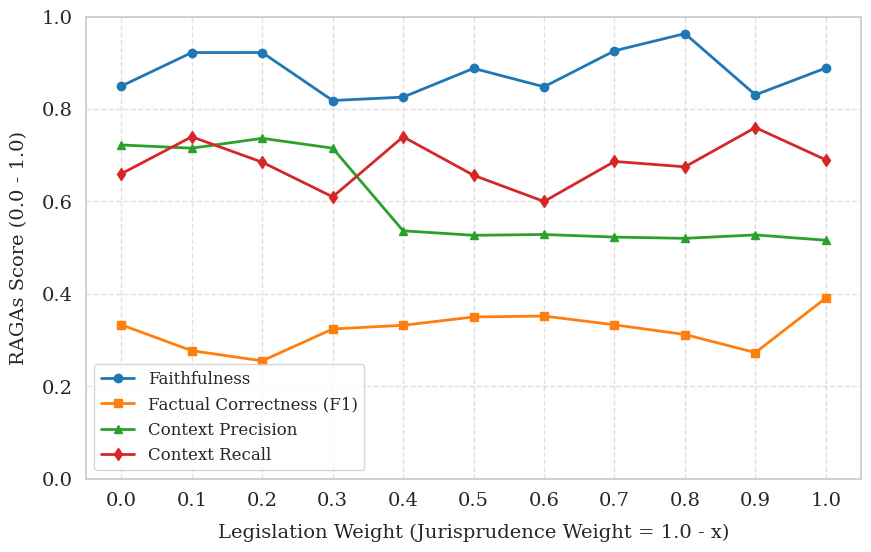

In [130]:
# theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,          
    'axes.labelsize': 16,      
    'xtick.labelsize': 14,    
    'ytick.labelsize': 14      
})

weights_list = np.linspace(0.0, 1.0, 11)

plt.figure(figsize=(10, 6))

# Plot performance curves utilizing standard hexadecimal color mapping for academic reporting
plt.plot(weights_list, faithfulness_scores, marker='o', label='Faithfulness', color='#1f77b4', linewidth=2)
plt.plot(weights_list, correctness_scores, marker='s', label='Factual Correctness (F1)', color='#ff7f0e', linewidth=2)
plt.plot(weights_list, precision_scores, marker='^', label='Context Precision', color='#2ca02c', linewidth=2)
plt.plot(weights_list, recall_scores, marker='d', label='Context Recall', color='#d62728', linewidth=2)

# Apply formatting labels adhering to empirical system evaluation guidelines
plt.xlabel('Legislation Weight (Jurisprudence Weight = 1.0 - x)', fontsize=14, labelpad=10)
plt.ylabel('RAGAs Score (0.0 - 1.0)', fontsize=14, labelpad=10)

plt.xticks(weights_list)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', prop={'size': 12})
plt.ylim(0.0, 1.0)

# Save high-resolution visualization for direct document integration
plt.savefig('hybrid_weights_optimization_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Visualisation Experiments

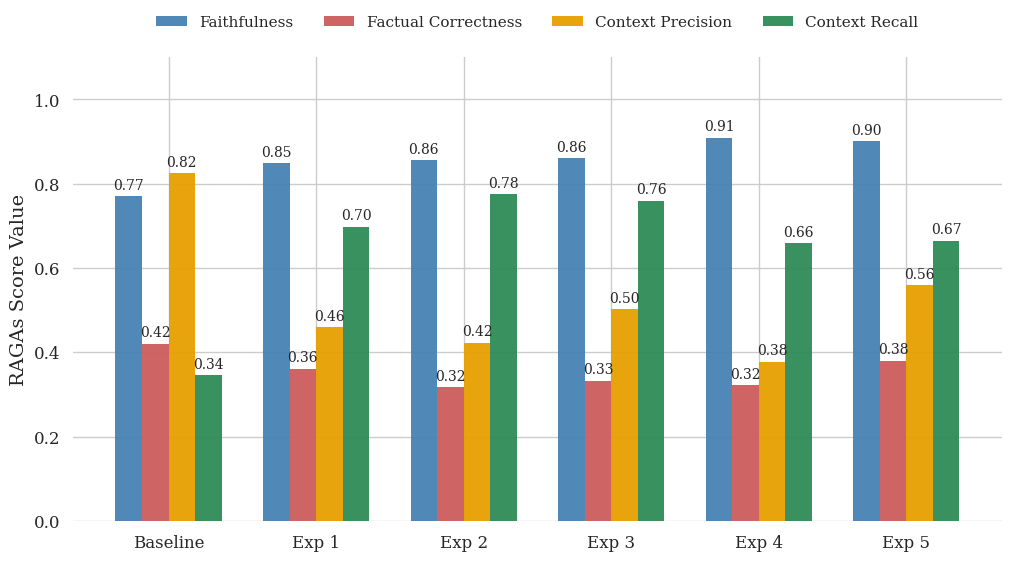

In [125]:
# Theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,          
    'axes.labelsize': 14,      
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12      
})

# Define the system configurations (X-axis categories)
experiments = ("Baseline", "Exp 1", "Exp 2", "Exp 3", "Exp 4", "Exp 5")

# Map RAGAs results 
ragas_metrics = {
    'Faithfulness': (0.7699, 0.8483, 0.85516, 0.8601, 0.9092, 0.9013),
    'Factual Correctness': (0.4200, 0.3610, 0.3170, 0.3320, 0.3220, 0.3800),
    'Context Precision': (0.8250, 0.4594, 0.4223, 0.5018, 0.3777, 0.5591),
    'Context Recall': (0.3450, 0.6983, 0.7750, 0.7600, 0.6583, 0.6650),
}

x = np.arange(len(experiments))  
width = 0.18  # Width of the individual bars 
multiplier = 0

# Color pallete
colors = ['#4682B4', '#CD5C5C', '#E69F00', '#2E8B57']

fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')

# Dynamic bar generation 
for (metric_name, scores), color in zip(ragas_metrics.items(), colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=metric_name, color=color, edgecolor='none', alpha=0.95)
    
    # Add micro-labels on top of bars
    ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=10)
    multiplier += 1

# Layout styling and labels
ax.set_ylabel('RAGAs Score Value')
ax.set_xticks(x + (width * 1.5), experiments)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=True, facecolor='white', edgecolor='none')
ax.set_ylim(0, 1.1)

# Clean chart borders
sns.despine(left=True, bottom=True)

# Save graph
plt.savefig('ragas_experiment_results.png', dpi=300, bbox_inches='tight')
plt.show()

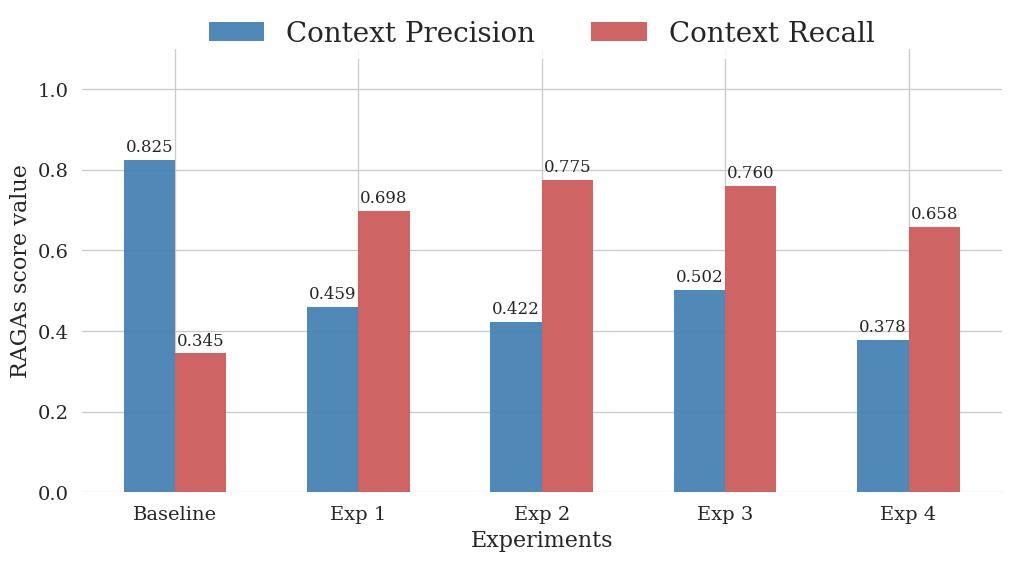

In [120]:
# Theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,          
    'axes.labelsize': 16,      
    'xtick.labelsize': 14,    
    'ytick.labelsize': 14      
})

# Define configurations (X-axis)
experiments = ("Baseline", "Exp 1", "Exp 2", "Exp 3", "Exp 4")

# Filtered RAGAs scores for SQ1 (retrieval metrics only)
retrieval_metrics = {
    'Context Precision': (0.8250, 0.4594, 0.4223, 0.5018, 0.3777),
    'Context Recall': (0.3450, 0.6983, 0.7750, 0.7600, 0.6583),
}

x = np.arange(len(experiments))  
width = 0.28  
multiplier = 0

# Color palette
colors = ['#4682B4', '#CD5C5C']

fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')

# Generate bars 
for (metric_name, scores), color in zip(retrieval_metrics.items(), colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=metric_name, color=color, edgecolor='none', alpha=0.95)
    
    # Add data labels on top of bars
    ax.bar_label(rects, padding=3, fmt='%.3f', fontsize=12)
    multiplier += 1

# Labels and tick positioning centered between the two bars
ax.set_ylabel('RAGAs score value')
ax.set_xlabel('Experiments')
ax.set_xticks(x + (width * 0.5), experiments)

# Legend settings
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=True, facecolor='white', edgecolor='none', prop={'size': 20})
ax.set_ylim(0, 1.1)

# Clean chart borders
sns.despine(left=True, bottom=True)

# Save graph 
plt.savefig('sq1_retrieval_results.png', dpi=300, bbox_inches='tight')
plt.show()

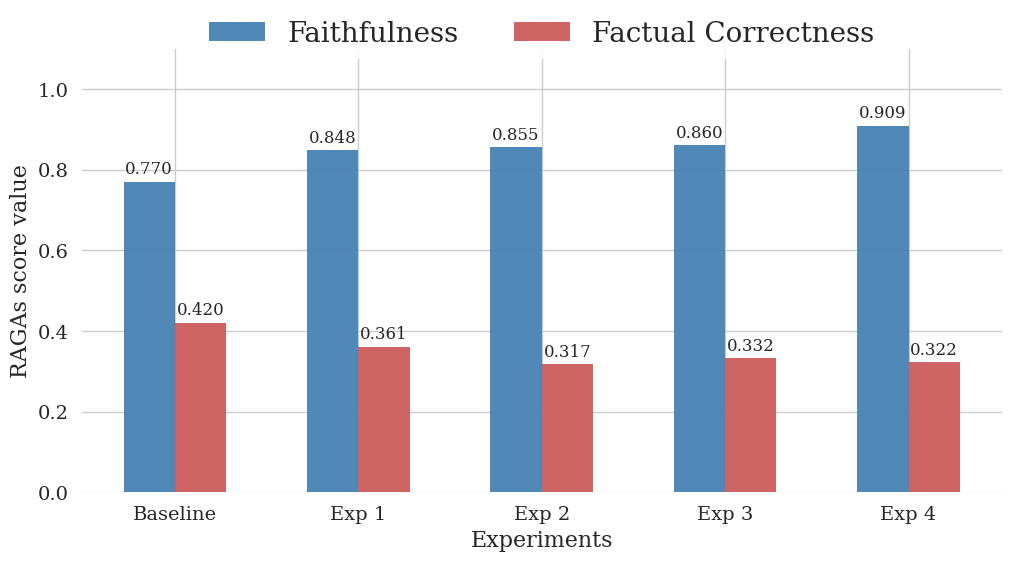

In [121]:
# Theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,          
    'axes.labelsize': 16,      
    'xtick.labelsize': 14,    
    'ytick.labelsize': 14      
})

# Define configurations (X-axis)
experiments = ("Baseline", "Exp 1", "Exp 2", "Exp 3", "Exp 4")

# Filtered RAGAs scores for SQ2 
generation_metrics = {
    'Faithfulness': (0.7699, 0.8483, 0.85516, 0.8601, 0.9092,),
    'Factual Correctness': (0.4200, 0.3610, 0.3170, 0.3320, 0.3220),
}

x = np.arange(len(experiments))  
width = 0.28  
multiplier = 0

# Color palette 
colors = ['#4682B4', '#CD5C5C']

fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')

# Generate bars 
for (metric_name, scores), color in zip(generation_metrics.items(), colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores, width, label=metric_name, color=color, edgecolor='none', alpha=0.95)
    
    # Add data labels on top of bars
    ax.bar_label(rects, padding=3, fmt='%.3f', fontsize=12)
    multiplier += 1

# Labels and tick positioning centered between the two bars
ax.set_ylabel('RAGAs score value')
ax.set_xlabel('Experiments')
ax.set_xticks(x + (width * 0.5), experiments)

# Legend settings
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=True, facecolor='white', edgecolor='none',  prop={'size': 20})
ax.set_ylim(0, 1.1)

# Clean chart borders
sns.despine(left=True, bottom=True)

# Save graph for Overleaf
plt.savefig('sq2_generation_results.png', dpi=300, bbox_inches='tight')
plt.show()